In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Paths
raw_path = "/content/drive/MyDrive/MutualFundAnalytics/Data/Raw"
processed_path = "/content/drive/MyDrive/MutualFundAnalytics/Data/Processed"
output_path = "/content/drive/MyDrive/MutualFundAnalytics/Reports"

os.makedirs(output_path, exist_ok=True)

# Load files
nav = pd.read_csv(f"{raw_path}/Copy of 02_nav_history.csv", parse_dates=['date'])
performance = pd.read_csv(f"{processed_path}/clean_scheme_performance.csv")
benchmark = pd.read_csv(f"{raw_path}/Copy of 10_benchmark_indices.csv")

print("✅ Files loaded!")
print(f"nav:         {nav.shape}")
print(f"performance: {performance.shape}")
print(f"benchmark:   {benchmark.shape}")
print("\nBenchmark columns:", benchmark.columns.tolist())
print("\nBenchmark sample:")
print(benchmark.head(3))

✅ Files loaded!
nav:         (46000, 3)
performance: (40, 19)
benchmark:   (8050, 3)

Benchmark columns: ['date', 'index_name', 'close_value']

Benchmark sample:
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05


Benchmark indices: ['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']

Daily Return Statistics:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Total return rows:   46000
Non-null returns:    45960
Null returns (first row of each fund): 40

Extreme return days (>10% or <-10%): 0


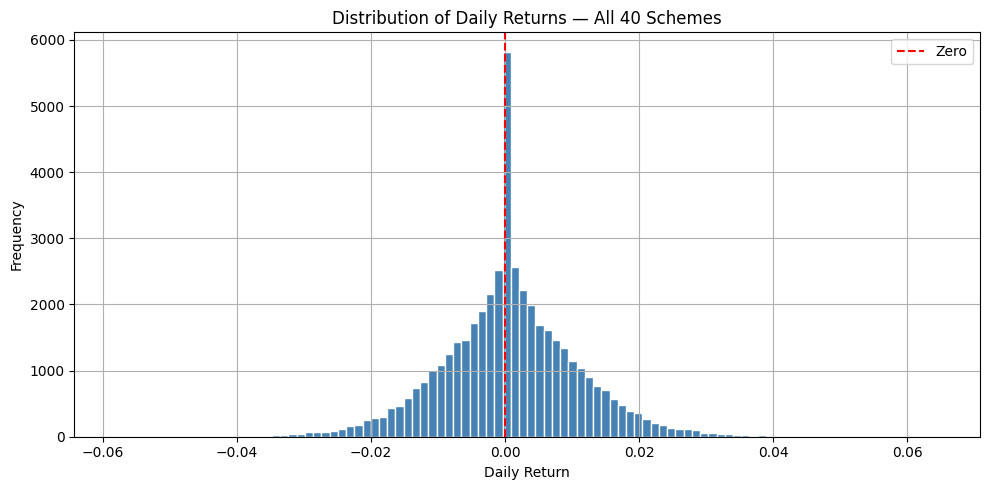

✅ Task 1 Complete — Daily returns computed!


In [16]:
# Check benchmark index names
print("Benchmark indices:", benchmark['index_name'].unique())

# Sort nav data
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)

# Compute daily returns for all 40 schemes
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Validate distribution
print("\nDaily Return Statistics:")
print(nav['daily_return'].describe())

print(f"\nTotal return rows:   {len(nav)}")
print(f"Non-null returns:    {nav['daily_return'].notna().sum()}")
print(f"Null returns (first row of each fund): {nav['daily_return'].isna().sum()}")

# Check reasonable range (-10% to +10%)
extreme = nav[
    (nav['daily_return'] < -0.10) |
    (nav['daily_return'] > 0.10)
]
print(f"\nExtreme return days (>10% or <-10%): {len(extreme)}")

# Plot distribution
plt.figure(figsize=(10, 5))
nav['daily_return'].dropna().hist(bins=100, color='steelblue', edgecolor='white')
plt.title('Distribution of Daily Returns — All 40 Schemes')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Zero')
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_path}/chart_daily_return_dist.png", dpi=150)
plt.show()
print("✅ Task 1 Complete — Daily returns computed!")

In [17]:
# Get first and last NAV for each fund
nav_sorted = nav.sort_values(['amfi_code', 'date'])

# Reference dates
date_end = nav_sorted['date'].max()
date_1yr = date_end - pd.DateOffset(years=1)
date_3yr = date_end - pd.DateOffset(years=3)
date_5yr = date_end - pd.DateOffset(years=5)

print(f"End date:   {date_end.date()}")
print(f"1yr start:  {date_1yr.date()}")
print(f"3yr start:  {date_3yr.date()}")
print(f"5yr start:  {date_5yr.date()}")

def get_nav_nearest(df, amfi_code, target_date):
    fund_data = df[df['amfi_code'] == amfi_code].copy()
    nearest = fund_data.iloc[(fund_data['date'] - target_date).abs().argsort()[:1]]
    return nearest['nav'].values[0]

def compute_cagr(nav_start, nav_end, years):
    if nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / years) - 1

# Compute CAGR for all funds
cagr_records = []

for amfi_code in nav_sorted['amfi_code'].unique():
    nav_end_val   = get_nav_nearest(nav_sorted, amfi_code, date_end)
    nav_1yr_val   = get_nav_nearest(nav_sorted, amfi_code, date_1yr)
    nav_3yr_val   = get_nav_nearest(nav_sorted, amfi_code, date_3yr)
    nav_5yr_val   = get_nav_nearest(nav_sorted, amfi_code, date_5yr)

    cagr_records.append({
        'amfi_code':  amfi_code,
        'cagr_1yr':   round(compute_cagr(nav_1yr_val, nav_end_val, 1) * 100, 2),
        'cagr_3yr':   round(compute_cagr(nav_3yr_val, nav_end_val, 3) * 100, 2),
        'cagr_5yr':   round(compute_cagr(nav_5yr_val, nav_end_val, 5) * 100, 2),
    })

cagr_df = pd.DataFrame(cagr_records)

# Merge with scheme names
cagr_df = cagr_df.merge(
    performance[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code', how='left'
)

print("\nCAGR Comparison Table (Top 10 by 3yr CAGR):")
print(cagr_df.sort_values('cagr_3yr', ascending=False)[
    ['scheme_name', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']
].head(10).to_string(index=False))

print("\n✅ Task 2 Complete — CAGR computed!")

End date:   2026-05-29
1yr start:  2025-05-29
3yr start:  2023-05-29
5yr start:  2021-05-29

CAGR Comparison Table (Top 10 by 3yr CAGR):
                                       scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
               Axis Midcap Fund - Regular - Growth     22.26     35.11     24.45
     Mirae Asset Large Cap Fund - Regular - Growth     20.36     34.00     26.80
         ICICI Pru Bluechip Fund - Direct - Growth     13.06     32.49     20.23
HDFC Mid-Cap Opportunities Fund - Regular - Growth     53.23     32.44     26.07
          ICICI Pru Midcap Fund - Regular - Growth     29.60     31.78     28.38
         SBI Bluechip Fund - Regular Plan - Growth     60.44     30.46     22.38
            Kotak Flexicap Fund - Regular - Growth     26.66     29.58     26.74
     Mirae Asset Tax Saver Fund - Regular - Growth     39.75     29.18     27.63
     ABSL Frontline Equity Fund - Regular - Growth     47.92     28.97     20.44
             DSP Small Cap Fund - Regular - Growth   

In [19]:
# Risk-free rate (RBI repo rate proxy)
Rf_daily = 0.065 / 252

sharpe_sortino_records = []

for amfi_code in nav['amfi_code'].unique():
    fund_returns = nav[nav['amfi_code'] == amfi_code]['daily_return'].dropna()

    if len(fund_returns) < 30:
        continue

    # Excess returns
    excess_returns = fund_returns - Rf_daily

    # Sharpe Ratio
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)

    # Sortino Ratio (downside std only)
    downside_returns = excess_returns[excess_returns < 0]
    downside_std = downside_returns.std()
    sortino = (excess_returns.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else np.nan

    sharpe_sortino_records.append({
        'amfi_code': amfi_code,
        'sharpe_ratio': round(sharpe, 4),
        'sortino_ratio': round(sortino, 4),
        'annual_return_pct': round(fund_returns.mean() * 252 * 100, 2),
        'annual_std_pct': round(fund_returns.std() * np.sqrt(252) * 100, 2)
    })

ratios_df = pd.DataFrame(sharpe_sortino_records)

# Merge with scheme names
ratios_df = ratios_df.merge(
    performance[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code', how='left'
)

# Rank by Sharpe
ratios_df['sharpe_rank'] = ratios_df['sharpe_ratio'].rank(ascending=False).astype(int)

print("Top 10 Funds by Sharpe Ratio:")
print(ratios_df.sort_values('sharpe_ratio', ascending=False)[
    ['scheme_name', 'sharpe_ratio', 'sortino_ratio', 'sharpe_rank']
].head(10).to_string(index=False))

print("\n✅ Task 3 & 4 Complete — Sharpe + Sortino computed!")

Top 10 Funds by Sharpe Ratio:
                                       scheme_name  sharpe_ratio  sortino_ratio  sharpe_rank
     Mirae Asset Large Cap Fund - Regular - Growth        1.4483         2.3683            1
            Kotak Flexicap Fund - Regular - Growth        1.3067         2.3529            2
     Mirae Asset Tax Saver Fund - Regular - Growth        1.2349         2.1351            3
         SBI Bluechip Fund - Regular Plan - Growth        1.2083         2.1040            4
          ICICI Pru Midcap Fund - Regular - Growth        1.1801         2.0100            5
                DSP Midcap Fund - Regular - Growth        1.1321         1.8689            6
HDFC Mid-Cap Opportunities Fund - Regular - Growth        1.0937         1.8238            7
    Nippon India Large Cap Fund - Regular - Growth        1.0817         1.8399            8
     ABSL Frontline Equity Fund - Regular - Growth        1.0272         1.7856            9
         ICICI Pru Bluechip Fund - Direc

In [20]:
# Prepare Nifty 100 benchmark returns
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['date'] = pd.to_datetime(nifty100['date'])
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna()

alpha_beta_records = []

for amfi_code in nav['amfi_code'].unique():
    # Get fund daily returns
    fund_data = nav[nav['amfi_code'] == amfi_code][['date', 'daily_return']].dropna()
    fund_data['date'] = pd.to_datetime(fund_data['date'])

    # Merge with benchmark
    merged = fund_data.merge(nifty100[['date', 'benchmark_return']], on='date', how='inner')

    if len(merged) < 30:
        continue

    # OLS Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    alpha_annual = intercept * 252 * 100  # annualized in %
    beta = slope
    r_squared = r_value ** 2

    alpha_beta_records.append({
        'amfi_code': amfi_code,
        'alpha': round(alpha_annual, 4),
        'beta': round(beta, 4),
        'r_squared': round(r_squared, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_records)

# Merge with scheme names
alpha_beta_df = alpha_beta_df.merge(
    performance[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code', how='left'
)

print("Top 10 Funds by Alpha:")
print(alpha_beta_df.sort_values('alpha', ascending=False)[
    ['scheme_name', 'alpha', 'beta', 'r_squared']
].head(10).to_string(index=False))

# Save alpha_beta.csv
alpha_beta_df.to_csv(f"{output_path}/alpha_beta.csv", index=False)
print("\n✅ Task 5 Complete — Alpha & Beta computed!")
print("✅ alpha_beta.csv saved!")

Top 10 Funds by Alpha:
                                       scheme_name   alpha    beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth 30.3370 -0.0232     0.0001
             DSP Small Cap Fund - Regular - Growth 30.0579  0.0115     0.0000
          ICICI Pru Midcap Fund - Regular - Growth 29.2636  0.0005     0.0000
     Mirae Asset Tax Saver Fund - Regular - Growth 28.2704  0.0181     0.0002
            Kotak Flexicap Fund - Regular - Growth 27.3305 -0.0228     0.0003
HDFC Mid-Cap Opportunities Fund - Regular - Growth 27.1954  0.0051     0.0000
     Mirae Asset Large Cap Fund - Regular - Growth 26.9838  0.0237     0.0005
                DSP Midcap Fund - Regular - Growth 26.5986 -0.0025     0.0000
               Axis Midcap Fund - Regular - Growth 26.0767 -0.0663     0.0019
         SBI Bluechip Fund - Regular Plan - Growth 23.2010 -0.0318     0.0009

✅ Task 5 Complete — Alpha & Beta computed!
✅ alpha_beta.csv saved!


In [21]:
drawdown_records = []

for amfi_code in nav['amfi_code'].unique():
    fund_data = nav[nav['amfi_code'] == amfi_code].sort_values('date').copy()

    # Running maximum
    fund_data['running_max'] = fund_data['nav'].cummax()

    # Drawdown at each point
    fund_data['drawdown'] = (fund_data['nav'] / fund_data['running_max']) - 1

    # Maximum drawdown
    max_dd = fund_data['drawdown'].min()
    max_dd_date = fund_data.loc[fund_data['drawdown'].idxmin(), 'date']

    # Peak date (before max drawdown)
    peak_date = fund_data.loc[
        fund_data['nav'][:fund_data['drawdown'].idxmin()].idxmax(), 'date'
    ]

    drawdown_records.append({
        'amfi_code': amfi_code,
        'max_drawdown_pct': round(max_dd * 100, 2),
        'peak_date': peak_date.date(),
        'trough_date': max_dd_date.date()
    })

drawdown_df = pd.DataFrame(drawdown_records)

# Merge with scheme names
drawdown_df = drawdown_df.merge(
    performance[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code', how='left'
)

print("Top 10 Worst Drawdowns:")
print(drawdown_df.sort_values('max_drawdown_pct')[
    ['scheme_name', 'max_drawdown_pct', 'peak_date', 'trough_date']
].head(10).to_string(index=False))

print("\n✅ Task 6 Complete — Maximum Drawdown computed!")

Top 10 Worst Drawdowns:
                                   scheme_name  max_drawdown_pct  peak_date trough_date
     SBI Small Cap Fund - Direct Plan - Growth            -52.57 2023-01-17  2025-10-28
        Axis Small Cap Fund - Regular - Growth            -51.68 2025-05-22  2026-05-11
        ABSL Small Cap Fund - Regular - Growth            -35.45 2024-11-21  2026-05-11
         DSP Small Cap Fund - Regular - Growth            -31.17 2026-04-24  2025-01-03
    SBI Small Cap Fund - Regular Plan - Growth            -28.71 2026-05-22  2025-05-14
           UTI Mid Cap Fund - Regular - Growth            -28.00 2025-01-07  2026-04-27
     HDFC Top 100 Fund - Regular Plan - Growth            -24.73 2022-03-30  2022-09-15
 Kotak Emerging Equity Fund - Regular - Growth            -24.00 2025-10-22  2024-10-17
Nippon India Small Cap Fund - Regular - Growth            -23.34 2026-05-08  2026-02-20
          Axis Bluechip Fund - Direct - Growth            -21.75 2025-12-02  2023-05-22

✅ Task 

In [22]:
# Merge all metrics together
scorecard_df = performance[['amfi_code', 'scheme_name', 'category',
                             'return_3yr_pct', 'expense_ratio_pct']].copy()

# Add Sharpe rank
scorecard_df = scorecard_df.merge(
    ratios_df[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left'
)

# Add Alpha
scorecard_df = scorecard_df.merge(
    alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code', how='left'
)

# Add Max Drawdown
scorecard_df = scorecard_df.merge(
    drawdown_df[['amfi_code', 'max_drawdown_pct']], on='amfi_code', how='left'
)

# Add CAGR 3yr
scorecard_df = scorecard_df.merge(
    cagr_df[['amfi_code', 'cagr_3yr']], on='amfi_code', how='left'
)

n = len(scorecard_df)

# Compute ranks (higher is better)
scorecard_df['rank_3yr_return']    = scorecard_df['cagr_3yr'].rank(ascending=True)
scorecard_df['rank_sharpe']        = scorecard_df['sharpe_ratio'].rank(ascending=True)
scorecard_df['rank_alpha']         = scorecard_df['alpha'].rank(ascending=True)
scorecard_df['rank_expense']       = scorecard_df['expense_ratio_pct'].rank(ascending=False)  # inverse
scorecard_df['rank_max_dd']        = scorecard_df['max_drawdown_pct'].rank(ascending=False)   # inverse

# Composite Score (0-100)
scorecard_df['score'] = (
    0.30 * scorecard_df['rank_3yr_return'] +
    0.25 * scorecard_df['rank_sharpe'] +
    0.20 * scorecard_df['rank_alpha'] +
    0.15 * scorecard_df['rank_expense'] +
    0.10 * scorecard_df['rank_max_dd']
)

# Normalize to 0-100
scorecard_df['score_100'] = (
    (scorecard_df['score'] - scorecard_df['score'].min()) /
    (scorecard_df['score'].max() - scorecard_df['score'].min()) * 100
).round(2)

# Final ranking
scorecard_df['final_rank'] = scorecard_df['score_100'].rank(ascending=False).astype(int)
scorecard_df = scorecard_df.sort_values('final_rank')

print("🏆 Top 10 Funds — Fund Scorecard:")
print(scorecard_df[['final_rank', 'scheme_name', 'score_100',
                     'cagr_3yr', 'sharpe_ratio', 'alpha']
].head(10).to_string(index=False))

# Save
scorecard_df.to_csv(f"{output_path}/fund_scorecard.csv", index=False)
print("\n✅ Task 7 Complete — Fund Scorecard computed!")
print("✅ fund_scorecard.csv saved!")

🏆 Top 10 Funds — Fund Scorecard:
 final_rank                                        scheme_name  score_100  cagr_3yr  sharpe_ratio   alpha
          1           ICICI Pru Midcap Fund - Regular - Growth     100.00     31.78        1.1801 29.2636
          2                Axis Midcap Fund - Regular - Growth      94.20     35.11        0.9982 26.0767
          3 HDFC Mid-Cap Opportunities Fund - Regular - Growth      93.82     32.44        1.0937 27.1954
          4      Mirae Asset Large Cap Fund - Regular - Growth      93.04     34.00        1.4483 26.9838
          5             Kotak Flexicap Fund - Regular - Growth      90.34     29.58        1.3067 27.3305
          6          ICICI Pru Bluechip Fund - Direct - Growth      86.47     32.49        1.0265 21.1948
          7         SBI Small Cap Fund - Regular Plan - Growth      85.51     26.67        0.9453 30.3370
          8              DSP Small Cap Fund - Regular - Growth      85.22     27.00        0.9498 30.0579
          9  

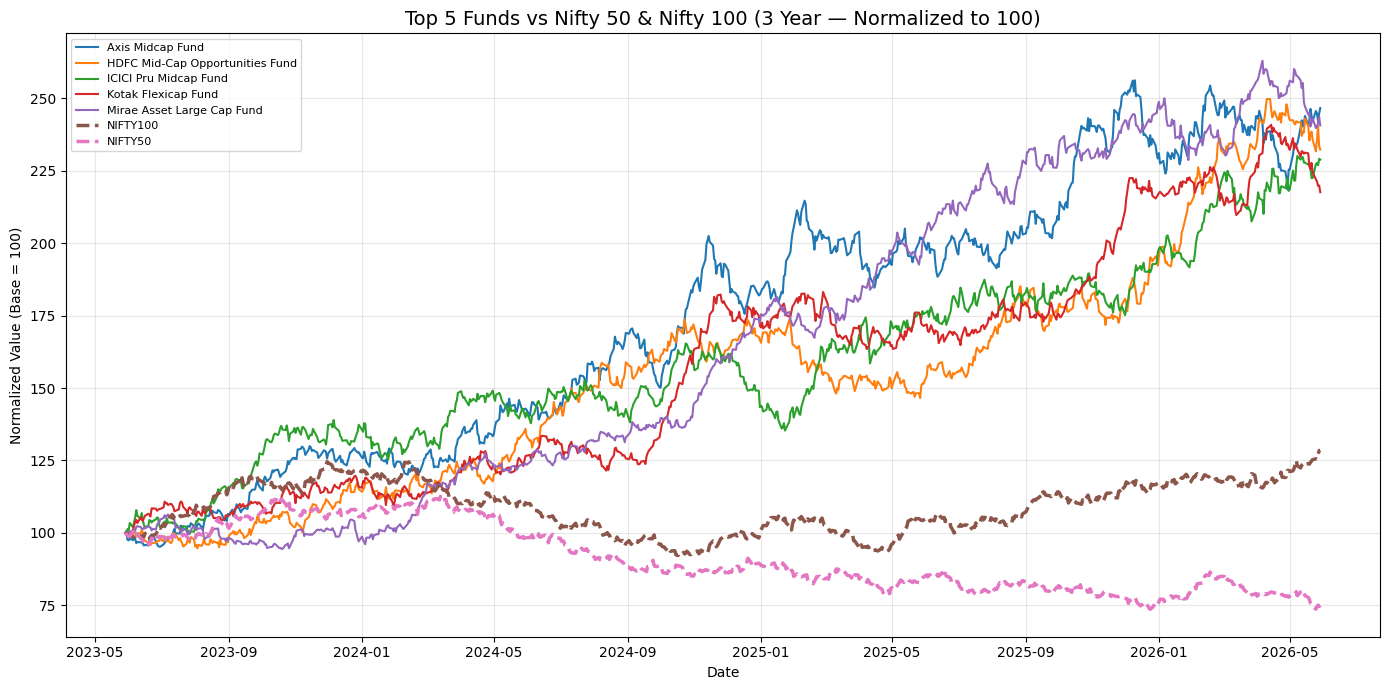


Tracking Error vs NIFTY100:
  ICICI Pru Midcap Fund - Regular - Growth      TE: 23.27%
  Axis Midcap Fund - Regular - Growth           TE: 23.98%
  HDFC Mid-Cap Opportunities Fund - Regular - G TE: 22.50%
  Mirae Asset Large Cap Fund - Regular - Growth TE: 18.80%
  Kotak Flexicap Fund - Regular - Growth        TE: 20.65%

✅ Task 8 Complete — Benchmark chart saved!


In [23]:
# Top 5 funds from scorecard
top5_codes = scorecard_df.head(5)['amfi_code'].tolist()
top5_names = scorecard_df.head(5)[['amfi_code', 'scheme_name']].set_index('amfi_code')['scheme_name'].to_dict()

# Filter nav for top 5 funds — last 3 years
date_3yr = nav['date'].max() - pd.DateOffset(years=3)
nav_top5 = nav[
    (nav['amfi_code'].isin(top5_codes)) &
    (nav['date'] >= date_3yr)
].copy()

# Normalize NAV to 100 (base = first date)
def normalize(group):
    group = group.sort_values('date')
    group['nav_normalized'] = group['nav'] / group['nav'].iloc[0] * 100
    return group

nav_top5 = nav_top5.groupby('amfi_code', group_keys=False).apply(normalize)
nav_top5['scheme_name'] = nav_top5['amfi_code'].map(top5_names)

# Prepare benchmark (Nifty50 + Nifty100) — last 3 years
for index_name in ['NIFTY50', 'NIFTY100']:
    bm = benchmark[
        (benchmark['index_name'] == index_name) &
        (pd.to_datetime(benchmark['date']) >= date_3yr)
    ].copy()
    bm = bm.sort_values('date')
    bm['nav_normalized'] = bm['close_value'] / bm['close_value'].iloc[0] * 100
    bm['scheme_name'] = index_name
    bm['date'] = pd.to_datetime(bm['date'])
    bm = bm.rename(columns={'close_value': 'nav'})
    nav_top5 = pd.concat([nav_top5, bm[['date', 'nav', 'nav_normalized', 'scheme_name']]])

# Plot
plt.figure(figsize=(14, 7))

for name, group in nav_top5.groupby('scheme_name'):
    group = group.sort_values('date')
    if name in ['NIFTY50', 'NIFTY100']:
        plt.plot(group['date'], group['nav_normalized'],
                linewidth=2.5, linestyle='--', label=name)
    else:
        short_name = name.split(' - ')[0]
        plt.plot(group['date'], group['nav_normalized'],
                linewidth=1.5, label=short_name)

plt.title('Top 5 Funds vs Nifty 50 & Nifty 100 (3 Year — Normalized to 100)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Value (Base = 100)')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_path}/benchmark_comparison.png", dpi=150)
plt.show()

# Tracking Error
print("\nTracking Error vs NIFTY100:")
nifty100_ret = benchmark[
    (benchmark['index_name'] == 'NIFTY100') &
    (pd.to_datetime(benchmark['date']) >= date_3yr)
].copy()
nifty100_ret['date'] = pd.to_datetime(nifty100_ret['date'])
nifty100_ret['bm_return'] = nifty100_ret['close_value'].pct_change()

for amfi_code in top5_codes:
    fund_ret = nav[
        (nav['amfi_code'] == amfi_code) &
        (nav['date'] >= date_3yr)
    ][['date', 'daily_return']].copy()

    merged = fund_ret.merge(nifty100_ret[['date', 'bm_return']], on='date', how='inner')
    tracking_error = (merged['daily_return'] - merged['bm_return']).std() * np.sqrt(252) * 100

    print(f"  {top5_names[amfi_code][:45]:<45} TE: {tracking_error:.2f}%")

print("\n✅ Task 8 Complete — Benchmark chart saved!")